# MNIST Baseline Model

## Objective

In this notebook, we will establish a simple neural-network baseline for MNIST digit classification.

The baseline will use fully connected (`Linear`) layers without convolution.

The purpose of this model is not to achieve the best possible accuracy. Instead, it provides a reference point that we can later compare against more specialized image architectures.

## Workflow

1. Load and prepare MNIST
2. Create a simple fully connected neural network
3. Define the loss function and optimizer
4. Train the model
5. Evaluate its performance
6. Analyze its errors
7. Record conclusions for comparison with the future CNN

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device: ", device)

Using device:  cpu


Loading the dataset

In [8]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root = "../../data/raw",
    train = True,
    download = True,
    transform = transform
)

test_dataset = torchvision.datasets.MNIST(
    root = "../../data/raw",
    train = False,
    download = True,
    transform = transform
)

100.0%
100.0%
100.0%
100.0%


## Creating DataLoaders

A neural network is normally trained using mini-batches rather than processing the entire training dataset at once.

A `DataLoader` handles:

- grouping samples into batches
- shuffling the training data
- iterating over the dataset efficiently

We will initially use a batch size of 64.

In [9]:
batch_size = 64

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size = batch_size,
    shuffle = True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size = batch_size,
    shuffle = False
)

In [10]:
images, labels = next(iter(train_loader))

print("Images shape: ", images.shape)
print("Labels shape: ", labels.shape)

Images shape:  torch.Size([64, 1, 28, 28])
Labels shape:  torch.Size([64])


## Baseline Architecture

The baseline model treats each image as a vector of 784 pixel values.

The model consists of:

- a flattening operation
- a fully connected layer from 784 to 128 features
- a ReLU activation
- a fully connected output layer from 128 to 10 classes

The ten output values correspond to the ten possible digits.

In [23]:
class BaseLineModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.network(x)

In [24]:
blmodel = BaseLineModel().to(device)

print(blmodel)

BaseLineModel(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [25]:
total_params = sum(
    parameter.numel()
    for parameter in blmodel.parameters()
)

print(f"Total parameters: {total_params:,}")

Total parameters: 101,770


In [26]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    blmodel.parameters(),
    lr = 0.001
)

## Training Loop

After deciding what loss function and optimizer to use, we can start working on the training loop.
The fundamental training process is: images -> forward pass -> predictions -> calculate loss -> backpropagation -> calculate gradients -> optimizer updates weights -> repeat

In [27]:
epochs = 5

train_losses = []

for epoch in range(epochs):
    blmodel.train()

    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = blmodel(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(f"Epoch {epoch + 1}/{epochs}" f"- Loss: {epoch_loss:.4f}")

Epoch 1/5- Loss: 0.3491
Epoch 2/5- Loss: 0.1637
Epoch 3/5- Loss: 0.1151
Epoch 4/5- Loss: 0.0867
Epoch 5/5- Loss: 0.0692


([<matplotlib.axis.XTick at 0x20d997f8b30>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5')])

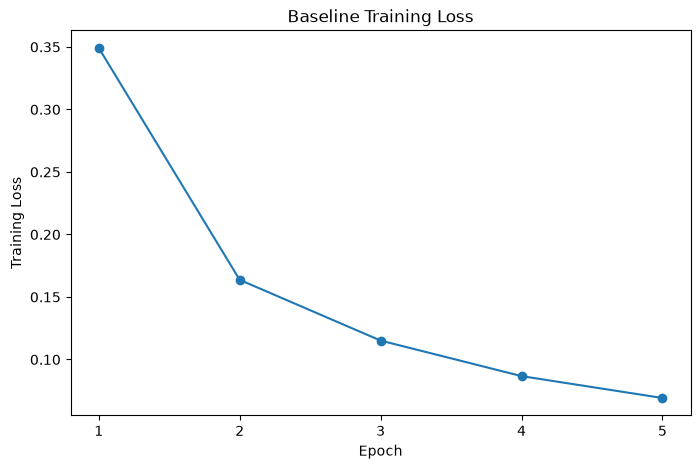

In [31]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, epochs + 1),
    train_losses,
    marker = "o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Baseline Training Loss")
plt.xticks(range(1, epochs + 1))